# AP 155 Lab Exercise
---
## Exercise 1: Idiomatic Python

_Instructions_: 
- **Report figure (Problem 1):** Plot the 2D wave interference pattern between 2 (or more) coherent sources. Include at least 1 figure.
- **Report discussion (Problem 2):** Write a custom `matrix_multiply()`function using Python list comprehensions without external libraries (do not use `np.dot()` or `@`).
    - (i) For larger matrices, which is preferred, the custom `matrix_multiply()` or the `@` operator... why?
    - (ii) What are the general benefits of writing idiomatic Python?
- **Code**: Complete the codes and ensure they are functional, error-free, readable, and efficient (where needed). Include a concise markdown documentation highlighting the critical steps of your algorithm for each problem.

### Student Information
- _Full Name (Last Name, First Name)_: Domingo, Judiele Fatima P.
- _Student No._: 2023-05167
- _Section_: THU-TX-1

### Grading Information (c/o Lab Instructor)
- [Rubrics description link](https://drive.google.com/file/d/1G9tPPcyMUag91g_R02O0wsGYPiZWy5Nn/view?usp=drive_link) (Note: percentages may still be tweaked)

| Criteria | Score | Subtotal |
| --- | --- | --- |
| Report figure | XX | 20 |
| Report discussion | XX | 20|
| Code readability | XX | 20 |
| Code efficiency | XX | 20 | 
| Code appropriateness  | XX | 20 | 
| **TOTAL** | XXX | 100 |

_Date and Time Scored (MM/DD/YYYY HH:MM AM/PM):_:_

---
## Section 1: Report

### Problem 1 

![2D Wave Interference Pattern](wave_interference.png)

**Figure 1:** Two-dimensional wave interference pattern plotting amplitude, W(r), as a function of x.
### Problem 2 

The exercise was focused on creating the matrix_multiply() function, which involved first creating 3 other functions to simplify testing. Thus, np.dot and @ operators are preferred for larger matrices as it is more efficient. In my experience, creating the function involved several stages like planning, writing, and debugging. Making use of readily available libraries skips these steps thus saving time. Since other functions are not needed when using numpy, it also saves on processing power and space. The main benefit of idiomatic python is its readability. By writing in idiomatic python multiple lines of code can be written into a concise one-liner. Another benefit is it is easier to understand when revisiting old code and others can also understand it intuitively. 
### Other comments
- I found it hard to rewrite my code in idiomatic python.

---
## Section 2: Code

### Problem 1: 2D Wave interference (Gezerlis Problem 1.15)

Assume that the combined eﬀect of two objects dropped in a water basin can be modelled by:
$$ W(\textbf{r}) = A \sin (k|\textbf{r}-\textbf{r}_0|) + A  \sin (k|\textbf{r}-\textbf{r}_1|). $$ You can think of this as an updated version of Eq. (1.3) in the book, where we are dealing with the linear addition of sinusoidal waves, instead of electric-field contributions. For simplicity, take $A=1$, $k=2\pi/0.3$, $r_0 = (−1, 0)$ , and $r_1 = (1, 0)$. Since we are now faced with a density plot, you should employ, NOT `streamplot()` but, `imshow()` from `Matplotlib`; in each of $x$ and $y$ your plot should extend from $−4$ to $+4$.

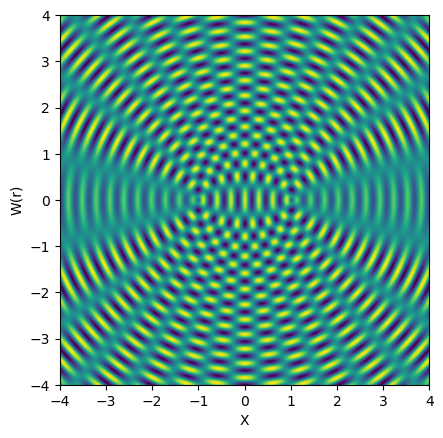

In [133]:
import matplotlib.pyplot as plt
import numpy as np
"""
1. contribution of wave 1
2. contribution of wave 2
3. density plot of W(r)
"""
#creating 
def wavefunction(x,y,r0x,r0y):
    A=1
    k=2*np.pi/0.3
    distance = np.sqrt((x-r0x)**2+(y-r0y)**2)
    return A*np.sin(k*distance)

#building a mesh grid and defining x and y
N=600
x = np.linspace(-4,4,N)
y = np.linspace(-4,4,N)
X, Y = np.meshgrid(x,y)

#calling wavvefunction function to get interference and contribution
wave1 = wavefunction(X,Y,-1,0)
wave2 = wavefunction(X,Y,1,0)
interference= wave1+wave2

#creating density plot using imshow()
plt.xlabel('X')
plt.ylabel('W(r)')
plt.xlim(-4,4)
plt.ylim(-4,4)
plt.imshow(interference, cmap='viridis', extent=[-4,4,-4,4], origin='lower')
plt.savefig('wave_interference.png') # saves plot as .png
plt.show()


#### Problem 1 code summary

Include a brief summary (2–3 sentences) at the bottom of your code outlining the purpose of the script and its core algorithm. Focus on explaining why you wrote the code this way and the reasoning behind your implementation choices.

---

### Problem 2: Listcomps-maxxing

Import the `random` library (docs: https://docs.python.org/3/library/random.html). We will be using the `random.randint` function to pick random integers.

In [8]:
import random
number = random.randint(1, 9)
number

8

a. Create a function `random_integer_matrix(nrows, ncols)` that generates a matrix in the form of "list-of-lists" whose elements are random integers from $1$ to $9$. Each "sub-list" inside the main list is a row in the matrix.

In [36]:
def random_integer_matrix(nrows, ncols):
    matrix=[]
    for row in range(nrows):
        row=[]
        for col in range(ncols):
            row.append(random.randint(1,9)) #adds ncols elements to row
            matrix.append(row) #appends each list as one row
        return matrix
    """ 
    1. create a list with ncols # of elements
    2. append new lists with ncols # of elements until nrows # of rows are created
    3. lists should be segregated: 3 lists w 4 elements in one list for a 3x4 matrix
    """

random_integer_matrix(3, 4) # call the function to create a 3x4 matrix

[[6, 7, 5, 6], [6, 7, 5, 6], [6, 7, 5, 6], [6, 7, 5, 6]]

b. Create a function `scalar_product(list1, list2)` where you multiply each element at the same index in the two lists and sum/accumulate the results.

In [222]:
"""
1. create 2 lists
2. get elements of same index - use zip
3. multiply elements of same index 
4. repeat 2&3 for n number of elements
5. add all products
"""
list_a=[1,2,3]
list_b=[4,5,6] #result should be 32
def scalar_product(list1,list2):
    '''
    non-idiomatic python
    products=[]
    for i,j in zip(list1,list2):
        product= i * j
        products.append(product)#creates a list of same index products
    '''
    products = [i*j for i,j in zip(list1,list2)]
    return sum(products)#sums all elements in product
scalar_product(list_a,list_b) #calls the function to perform scalar product

32

c. Create a function `transpose_matrix(orig_matrix)` which returns the transpose of any matrix also in "list-of-lists" form. Do not assume the size of the matrix; figure it out within the function. Double-check that your implementations above work. Create a $3\times4$ random integer matrix, print it out and its transpose. The values and shape between the two should be consistent.

In [223]:
'''
1. add placeholder matrix (function should work for any matrix)
2. get number of rows and columns
3. switch rows and columns
'''
#transposed Matrix A should show [[1,4],[2,5],[3,6]]
A = [[1,2,3],  [4,5,6]]

def transpose_matrix(orig_matrix):
    rows = len(orig_matrix) #counts number of lists in original matrix
    columns = len(orig_matrix[0]) #counts number of elements in the first nested list
    transpose = []
    for c in range(columns):
        transpose_row = [] #creates empty lists for c number of columns
        for r in range(rows):
            transpose_row.append(orig_matrix[r][c]) #adds cth element of rth nested list to transposed row
        transpose.append(transpose_row) #adds the completed transposed row to transposed matrix
    return transpose

transpose_matrix(A)

[[1, 4], [2, 5], [3, 6]]

d. Create a function `matrix_multiply(left_matrix, right_matrix)` which performs the matrix multiplication. Do not assume the matrices follow a specific shape. Here's some tips and strategies:
* Determine how many rows and columns the left and right matrices have. Which numbers should match in order for us to have valid matrix multiplication?
* Iterating the elements of "list-of-lists" gives us the rows, but we need to iterate the columns for the right matrix.
* Use the `transpose_matrix` function, then iteratively apply `scalar_product`.

In [224]:
"""
1. check if # of rows of matrix 1 is equal to rows of matrix 2
2. call transpose matrix func
3. call scalar_product func
"""
#placeholder matrices
matrix1 = [[1,2,3],[4,5,6]]
matrix2 = [[1,2],[3,4],[5,6]]
matrix3 = [[1,2,3],[4,5,6]]
#function to check if matrices are valid
def can_be_multiplied (left_matrix,right_matrix):
    left_columns = len(left_matrix[0]) #counts number of elements in first nested list
    right_rows = len(right_matrix) #counts number of nested lists
    return left_columns==right_rows
    
print('can you multiply matrix 1 and 2:', can_be_multiplied(matrix1,matrix2)) #should return true
print('can you multiply matrix 1 and 3:',can_be_multiplied(matrix1,matrix3)) #should return false

can you multiply matrix 1 and 2: True
can you multiply matrix 1 and 3: False


In [225]:
#function for matrix multiplication
def matrix_multiply(left_matrix, right_matrix):
    if not can_be_multiplied(left_matrix, right_matrix):
        raise ValueError("Number of columns in left_matrix must match number of rows in right_matrix")
    right_transposed = transpose_matrix(right_matrix) #switches rows and columns of right matrix to match with columns of left
    multiplied_result = []
    for left_row in left_matrix:
        multiplied_result_row = []
        for right_column in right_transposed:
            multiplied_result_row.append(scalar_product(left_row,right_column)) #gets the scalar product of one row and saves it to multiplied_result_row
        multiplied_result.append(multiplied_result_row) #saves all scalar product elements of one row to multiplied_result
    return multiplied_result
#performing matrix multiplication for matrix 1 and matrix 2
print('Matrix1 * Matrix2 = ', matrix_multiply(matrix1,matrix2))

Matrix1 * Matrix2 =  [[22, 28], [49, 64]]


In [220]:
#performing matrix multiplication for matrix 1 and matrix 3: should show value error
print('Matrix1 * Matrix3 = ', matrix_multiply(matrix1,matrix3))

ValueError: Number of columns in left_matrix must match number of rows in right_matrix

#### Problem 2 code summary

The code performs matrix multiplication by checking applicability then transposing the second matrix so that its columns align with the rows of the first matrix. Finally it gets the scalar product of each element and stores them into one matrix.. I wrote this code step by step following the outline I created as a guide, consequently, the code is not concise or idiomatic.